# Keras — multilayer perceptron (Iris)

Copia de trabajo de `05 Keras - multilayer perceptron - iris.ipynb`. Corre
primero la red original 4x3x3 y despues agrega dos capas `Dense(3,
sigmoid)` mas (4x3x3x3x3), sin cambiar alpha=0.03 ni 500 epocas.

In [1]:
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


## Red original (4 x 3 x 3)

In [4]:
tf.keras.utils.set_random_seed(42)
model_orig = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)
model_orig.summary()

C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.03)
loss = tf.keras.losses.MeanSquaredError()
model_orig.compile(optimizer, loss)

t0 = time.time()
history_orig = model_orig.fit(X, Y, epochs=500, verbose=0)
t_orig = time.time() - t0
print(f"Tiempo de entrenamiento (original): {t_orig:.1f} s")
print("Loss final (original):", history_orig.history["loss"][-1])

Tiempo de entrenamiento (original): 18.8 s
Loss final (original): 0.15090696513652802


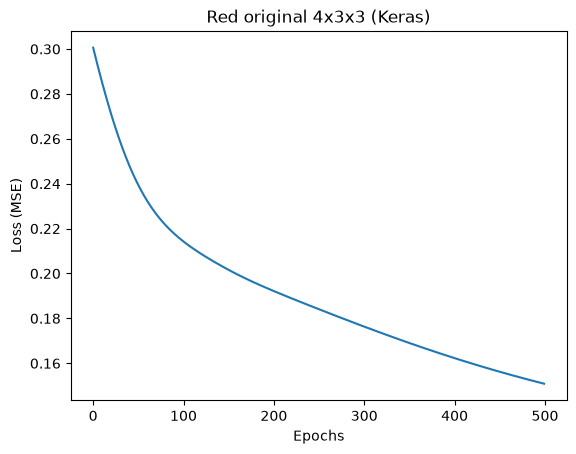

In [6]:
plt.plot(history_orig.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Red original 4x3x3 (Keras)")
plt.show()

In [7]:
model_orig.predict(np.array([[3, 3, 1, 1]]), verbose=0)

array([[0.51787317, 0.28180334, 0.19554122]], dtype=float32)

## Red profunda (4 x 3 x 3 x 3 x 3)

Dos `Dense(3, sigmoid)` mas antes de la capa de salida. `model.summary()` debe mostrar 4 capas Dense.

In [8]:
tf.keras.utils.set_random_seed(42)
model_deep = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
  ]
)
model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.03)
loss = tf.keras.losses.MeanSquaredError()
model_deep.compile(optimizer, loss)

t0 = time.time()
history_deep = model_deep.fit(X, Y, epochs=500, verbose=0)
t_deep = time.time() - t0
print(f"Tiempo de entrenamiento (profunda): {t_deep:.1f} s")
print("Loss final (profunda):", history_deep.history["loss"][-1])

Tiempo de entrenamiento (profunda): 18.7 s
Loss final (profunda): 0.22171811759471893


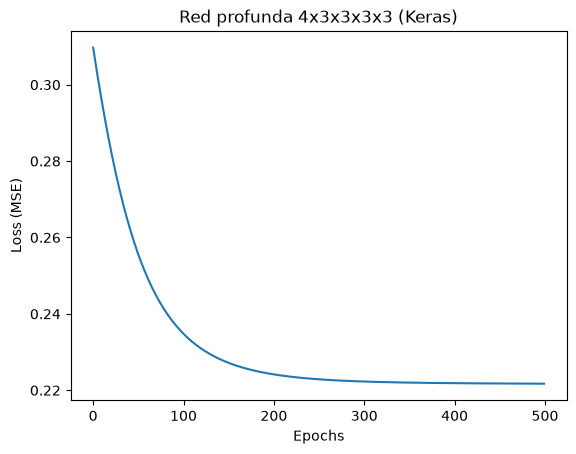

In [10]:
plt.plot(history_deep.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Red profunda 4x3x3x3x3 (Keras)")
plt.show()

## Comparacion original vs. profunda

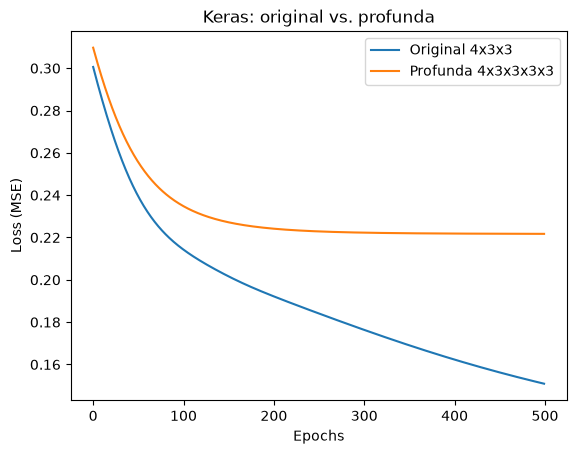

Loss final original: 0.15091 (18.8 s)
Loss final profunda: 0.22172 (18.7 s)


In [11]:
plt.plot(history_orig.history["loss"], label="Original 4x3x3")
plt.plot(history_deep.history["loss"], label="Profunda 4x3x3x3x3")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.title("Keras: original vs. profunda")
plt.show()
print(f"Loss final original: {history_orig.history['loss'][-1]:.5f} ({t_orig:.1f} s)")
print(f"Loss final profunda: {history_deep.history['loss'][-1]:.5f} ({t_deep:.1f} s)")

## Reto opcional

### a) ReLU en capas ocultas + softmax en la salida + categorical_crossentropy

Loss final (ReLU+softmax+CCE): 1.0987281799316406
Accuracy final: 0.3333333432674408


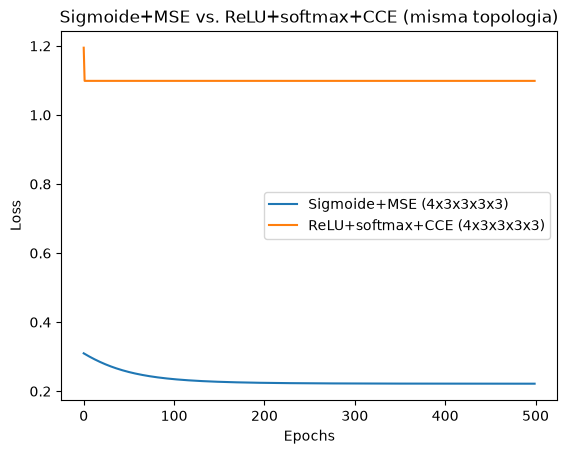

In [12]:
tf.keras.utils.set_random_seed(42)
model_relu = keras.Sequential(
  [
    layers.Dense(3, activation="relu", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="relu", name="layer2"),
    layers.Dense(3, activation="relu", name="layer3"),
    layers.Dense(3, activation="softmax", name="layer4"),
  ]
)
model_relu.compile(
    tf.keras.optimizers.SGD(learning_rate=0.03),
    tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)
history_relu = model_relu.fit(X, Y, epochs=500, verbose=0)
print("Loss final (ReLU+softmax+CCE):", history_relu.history["loss"][-1])
print("Accuracy final:", history_relu.history["accuracy"][-1])

plt.plot(history_deep.history["loss"], label="Sigmoide+MSE (4x3x3x3x3)")
plt.plot(history_relu.history["loss"], label="ReLU+softmax+CCE (4x3x3x3x3)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Sigmoide+MSE vs. ReLU+softmax+CCE (misma topologia)")
plt.show()

### b) Mas neuronas por capa oculta (4 x 8 x 8 x 8 x 3), con train/test split para ver sobreajuste

C:\Users\PC PRIDE OSTRICH PRO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Loss final train (4x8x8x8x3): 0.2227841317653656
Loss final val   (4x8x8x8x3): 0.22277745604515076


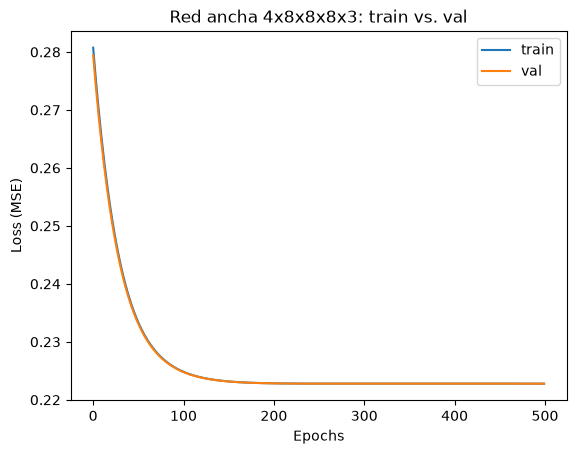

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=target
)

tf.keras.utils.set_random_seed(42)
model_wide = keras.Sequential(
  [
    layers.Dense(8, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(8, activation="sigmoid", name="layer2"),
    layers.Dense(8, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
  ]
)
model_wide.compile(tf.keras.optimizers.SGD(learning_rate=0.03), tf.keras.losses.MeanSquaredError())
history_wide = model_wide.fit(
    X_train, Y_train, epochs=500, verbose=0, validation_data=(X_test, Y_test)
)
print("Loss final train (4x8x8x8x3):", history_wide.history["loss"][-1])
print("Loss final val   (4x8x8x8x3):", history_wide.history["val_loss"][-1])

plt.plot(history_wide.history["loss"], label="train")
plt.plot(history_wide.history["val_loss"], label="val")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.title("Red ancha 4x8x8x8x3: train vs. val")
plt.show()